# Cross-Validation: Técnicas e Aplicações
## Do Conceito à Implementação Prática

---

## Sumário

1. O Problema da Validação Simples
2. Introdução ao Cross-Validation
3. K-Fold Cross-Validation
4. Stratified K-Fold Cross-Validation
5. Time Series Split Cross-Validation
6. Leave-One-Out Cross-Validation (LOOCV)
7. Comparação Prática
8. Quando Usar Cada Técnica
9. Implementação Completa

---
## 1. O Problema da Validação Simples

### Train/Test Split Tradicional

O método mais comum de validação:
```python
train_test_split(X, y, test_size=0.2)
```

Divide dados em:
- 80% Treino
- 20% Teste

### Problemas com Split Simples

**1. Dependência da Divisão Aleatória**
Diferentes splits podem dar resultados muito diferentes.

**2. Desperdício de Dados**
20% dos dados nunca são usados para treinar.

**3. Variância Alta**
Uma única avaliação pode não ser representativa.

**4. Pode Pegar Amostra "Sortuda" ou "Azarada"**
Por azar, conjunto de teste pode ser mais fácil ou difícil.

### Exemplo do Problema

Imagine dataset com 100 amostras:
- Split 1: Acurácia = 85%
- Split 2: Acurácia = 92%
- Split 3: Acurácia = 78%

Qual é a verdadeira performance do modelo?

---

In [2]:
# Setup inicial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    TimeSeriesSplit,
    LeaveOneOut,
    cross_val_score,
    cross_validate
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configurações
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas com sucesso")

Bibliotecas importadas com sucesso


In [3]:
# Criar dataset para demonstração
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

print("DATASET CRIADO")
print("="*70)
print(f"Total de amostras: {len(X)}")
print(f"Número de features: {X.shape[1]}")
print(f"Distribuição de classes:")
print(pd.Series(y).value_counts())

DATASET CRIADO
Total de amostras: 200
Número de features: 2
Distribuição de classes:
1    100
0    100
Name: count, dtype: int64


In [4]:
# Demonstrar variabilidade do train_test_split
results_simple_split = []

print("\nDEMONSTRAÇÃO: VARIABILIDADE DO TRAIN/TEST SPLIT")
print("="*70)

for i in range(10):
    # Split diferente a cada iteração (seed diferente)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i
    )

    # Treinar modelo
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)

    # Avaliar
    score = model.score(X_test, y_test)
    results_simple_split.append(score)

    if i < 5:
        print(f"Split {i+1}: Acurácia = {score:.4f} ({score*100:.2f}%)")

print(f"\nEstatísticas de 10 splits diferentes:")
print(f"Média:    {np.mean(results_simple_split):.4f}")
print(f"Std Dev:  {np.std(results_simple_split):.4f}")
print(f"Mínimo:   {np.min(results_simple_split):.4f}")
print(f"Máximo:   {np.max(results_simple_split):.4f}")
print(
    f"Variação: {np.max(results_simple_split) - np.min(results_simple_split):.4f}")

print("\nProblema: Qual resultado devemos confiar?")


DEMONSTRAÇÃO: VARIABILIDADE DO TRAIN/TEST SPLIT
Split 1: Acurácia = 0.9250 (92.50%)
Split 2: Acurácia = 0.9250 (92.50%)
Split 3: Acurácia = 0.8000 (80.00%)
Split 4: Acurácia = 0.8000 (80.00%)
Split 5: Acurácia = 0.8500 (85.00%)

Estatísticas de 10 splits diferentes:
Média:    0.8300
Std Dev:  0.0600
Mínimo:   0.7500
Máximo:   0.9250
Variação: 0.1750

Problema: Qual resultado devemos confiar?


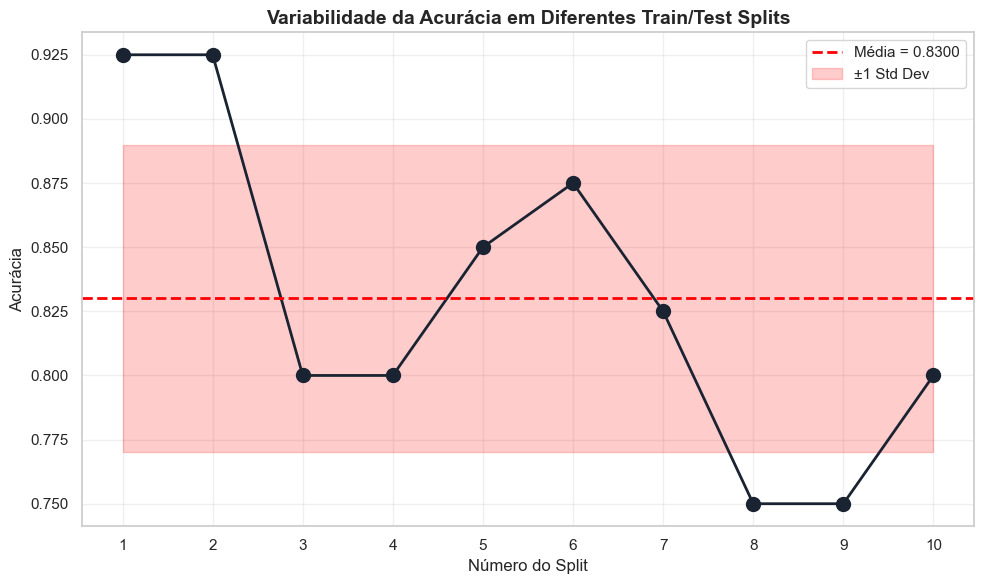

In [5]:
# Visualizar variabilidade
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), results_simple_split, marker='o', linewidth=2,
         markersize=10, color='#1A2332')
plt.axhline(np.mean(results_simple_split), color='red', linestyle='--',
            linewidth=2, label=f'Média = {np.mean(results_simple_split):.4f}')
plt.fill_between(range(1, 11),
                 np.mean(results_simple_split) - np.std(results_simple_split),
                 np.mean(results_simple_split) + np.std(results_simple_split),
                 alpha=0.2, color='red', label='±1 Std Dev')

plt.xlabel('Número do Split', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.title('Variabilidade da Acurácia em Diferentes Train/Test Splits',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

---
## 2. Introdução ao Cross-Validation

### O que é Cross-Validation?

**Definição:** Técnica de validação que divide o dataset em múltiplos subconjuntos e treina/testa o modelo várias vezes.

### Ideia Central

Em vez de um único split, fazer **múltiplos splits** e calcular a **média** dos resultados.

### Benefícios

1. Usa todos os dados para treino e teste
2. Reduz variância da estimativa
3. Avaliação mais confiável
4. Detecta overfitting melhor
5. Maximiza uso dos dados

### Processo Geral

Para cada fold:

- Separa uma parte para teste
- Usa o resto para treino
- Treina modelo
- Avalia no conjunto de teste
- Guarda resultado

Resultado final = Média de todos os folds

### Métricas

Além da média, também calculamos:
- Desvio padrão (variabilidade)
- Mínimo e máximo (range)
- Intervalo de confiança

---

---
## 3. K-Fold Cross-Validation

### Conceito

**K-Fold:** Divide dados em K partes (folds) iguais. Cada fold serve como teste uma vez.

### Algoritmo Passo a Passo

1. **Divide o dataset** em **K partes de tamanhos iguais**

2. **Para cada fold** \( i = 1, 2, \dots, K \):

   - **a)** Use fold *i* como o **conjunto de treino**
   - **b)** Use os **K − 1 folds** restantes como o **conjunto de treino**
   - **c)** **Treina** o model com o conjunto de treino
   - **d)** **Avalie** o modelo no conjunto de teste
   - **e)** **Armazene** a métrica de desempenho

   ### Fórmula

  $\text{Score}_{\text{final}} = \frac{1}{K} \sum_{i=1}^{K} \text{Score}_i$



### Parâmetros

**K (número de folds):**
- K = 5: Comum, balanço entre viés e variância
- K = 10: Mais comum, boa escolha padrão
- K = n: Leave-One-Out (caso extremo)

**Trade-offs:**
- K pequeno: Rápido, mais viés, menos variância
- K grande: Lento, menos viés, mais variância

### Vantagens

- Usa todos os dados
- Cada amostra é usada para teste exatamente uma vez
- Simples de entender
- Funciona bem na maioria dos casos

### Desvantagens

- Não garante distribuição de classes equilibrada
- Pode ser lento (treina K modelos)
- Pode ter dados dependentes em diferentes folds

### Quando Usar

- Dataset de tamanho médio a grande
- Classes balanceadas
- Dados independentes (não temporal)
- Avaliação padrão de modelos

---

In [6]:
# Implementação manual de K-Fold
def manual_k_fold(X, y, k=5):
    """
    Implementação manual de K-Fold para entendimento
    """
    n_samples = len(X)
    fold_size = n_samples // k
    indices = np.arange(n_samples)

    folds = []

    for i in range(k):
        # Definir índices de teste
        start = i * fold_size
        end = start + fold_size if i < k - 1 else n_samples
        test_indices = indices[start:end]

        # Definir índices de treino (todos exceto teste)
        train_indices = np.concatenate([indices[:start], indices[end:]])

        folds.append({
            'fold': i + 1,
            'train_indices': train_indices,
            'test_indices': test_indices,
            'train_size': len(train_indices),
            'test_size': len(test_indices)
        })

    return folds


# Demonstrar divisão
folds = manual_k_fold(X, y, k=5)

print("K-FOLD CROSS-VALIDATION (K=5)")
print("="*70)
print(f"\nTotal de amostras: {len(X)}")
print(f"Número de folds: 5")

for fold in folds:
    print(f"\nFold {fold['fold']}:")
    print(
        f"  Treino: {fold['train_size']} amostras ({fold['train_size']/len(X)*100:.1f}%)")
    print(
        f"  Teste:  {fold['test_size']} amostras ({fold['test_size']/len(X)*100:.1f}%)")

K-FOLD CROSS-VALIDATION (K=5)

Total de amostras: 200
Número de folds: 5

Fold 1:
  Treino: 160 amostras (80.0%)
  Teste:  40 amostras (20.0%)

Fold 2:
  Treino: 160 amostras (80.0%)
  Teste:  40 amostras (20.0%)

Fold 3:
  Treino: 160 amostras (80.0%)
  Teste:  40 amostras (20.0%)

Fold 4:
  Treino: 160 amostras (80.0%)
  Teste:  40 amostras (20.0%)

Fold 5:
  Treino: 160 amostras (80.0%)
  Teste:  40 amostras (20.0%)


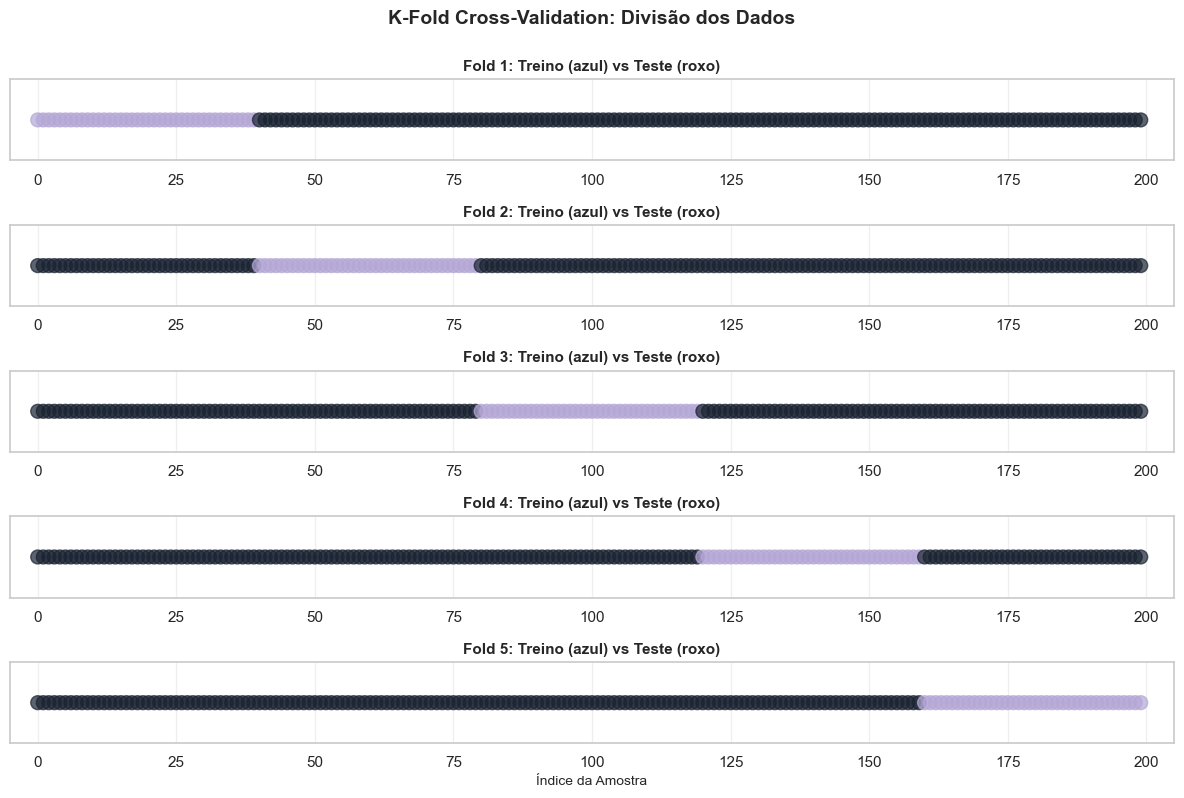

In [7]:
# Visualizar divisão dos folds
fig, axes = plt.subplots(5, 1, figsize=(12, 8))

for idx, fold in enumerate(folds):
    ax = axes[idx]

    # Criar array de cores
    colors_array = np.full(len(X), '#1A2332')  # Treino = azul escuro
    colors_array[fold['test_indices']] = '#B4A7D6'  # Teste = roxo

    # Plot
    ax.scatter(range(len(X)), [0]*len(X), c=colors_array, s=100, alpha=0.7)
    ax.set_xlim(-5, len(X)+5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_xlabel('Índice da Amostra' if idx == 4 else '', fontsize=10)
    ax.set_title(f'Fold {fold["fold"]}: Treino (azul) vs Teste (roxo)',
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

plt.suptitle('K-Fold Cross-Validation: Divisão dos Dados',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [8]:
# Implementar K-Fold com Scikit-Learn
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Treinar e avaliar
scores_kfold = []
fold_num = 1

print("\nEXECUÇÃO DO K-FOLD")
print("="*70)

for train_idx, test_idx in kfold.split(X):
    # Separar dados
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Treinar modelo
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)

    # Avaliar
    score = model.score(X_test, y_test)
    scores_kfold.append(score)

    print(f"Fold {fold_num}: Acurácia = {score:.4f} ({score*100:.2f}%)")
    fold_num += 1

print("\nRESULTADOS FINAIS:")
print(
    f"Média:       {np.mean(scores_kfold):.4f} ({np.mean(scores_kfold)*100:.2f}%)")
print(f"Std Dev:     {np.std(scores_kfold):.4f}")
print(f"Mínimo:      {np.min(scores_kfold):.4f}")
print(f"Máximo:      {np.max(scores_kfold):.4f}")
print(f"IC 95%:      [{np.mean(scores_kfold) - 1.96*np.std(scores_kfold):.4f}, "
      f"{np.mean(scores_kfold) + 1.96*np.std(scores_kfold):.4f}]")


EXECUÇÃO DO K-FOLD
Fold 1: Acurácia = 0.8750 (87.50%)
Fold 2: Acurácia = 0.8500 (85.00%)
Fold 3: Acurácia = 0.8250 (82.50%)
Fold 4: Acurácia = 0.8000 (80.00%)
Fold 5: Acurácia = 0.9000 (90.00%)

RESULTADOS FINAIS:
Média:       0.8500 (85.00%)
Std Dev:     0.0354
Mínimo:      0.8000
Máximo:      0.9000
IC 95%:      [0.7807, 0.9193]


In [9]:
# Usar cross_val_score (forma mais simples)
model = LogisticRegression(random_state=42)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("\nUSANDO cross_val_score (forma simplificada):")
print("="*70)
print(f"Scores por fold: {scores}")
print(f"Média: {scores.mean():.4f}")
print(f"Std:   {scores.std():.4f}")


USANDO cross_val_score (forma simplificada):
Scores por fold: [0.825 0.85  0.725 0.875 0.9  ]
Média: 0.8350
Std:   0.0604


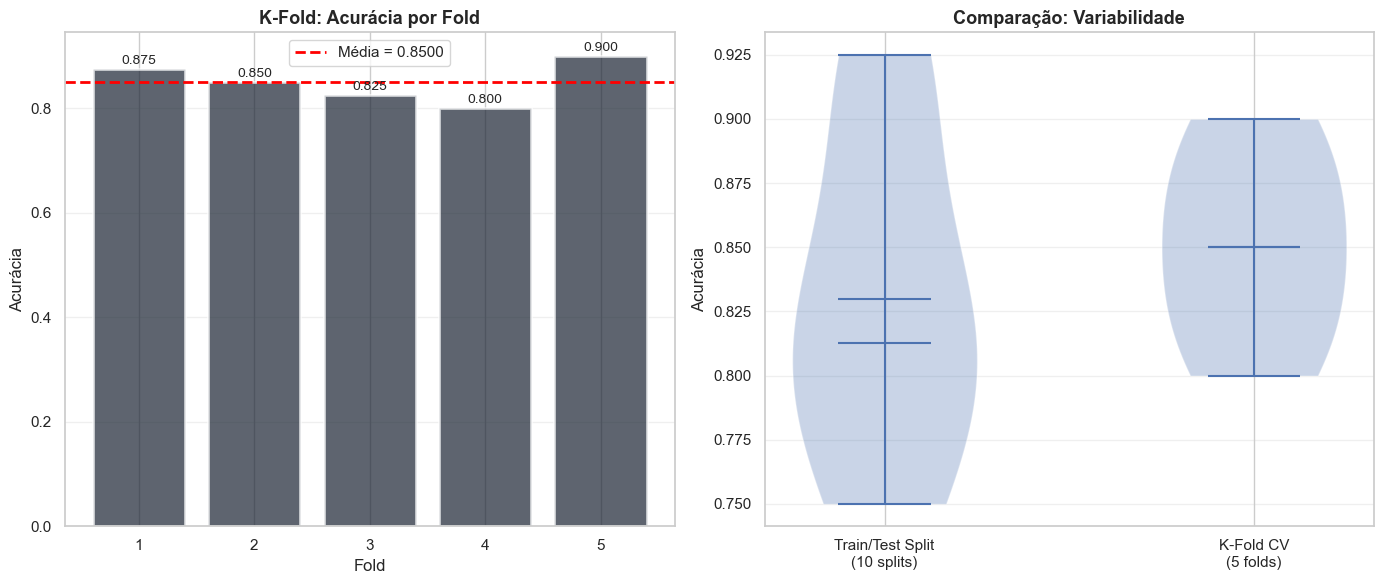


Observação: K-Fold tem menor variabilidade que múltiplos train/test splits


In [10]:
# Visualizar resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Scores por fold
axes[0].bar(range(1, 6), scores_kfold, color='#1A2332',
            alpha=0.7, edgecolor='white', linewidth=2)
axes[0].axhline(np.mean(scores_kfold), color='red', linestyle='--',
                linewidth=2, label=f'Média = {np.mean(scores_kfold):.4f}')
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('Acurácia', fontsize=12)
axes[0].set_title('K-Fold: Acurácia por Fold', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 6))
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, score in enumerate(scores_kfold):
    axes[0].text(i+1, score + 0.01, f'{score:.3f}', ha='center', fontsize=10)

# Gráfico 2: Comparação com train_test_split
axes[1].violinplot([results_simple_split, scores_kfold],
                   positions=[1, 2], showmeans=True, showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(
    ['Train/Test Split\n(10 splits)', 'K-Fold CV\n(5 folds)'])
axes[1].set_ylabel('Acurácia', fontsize=12)
axes[1].set_title('Comparação: Variabilidade', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nObservação: K-Fold tem menor variabilidade que múltiplos train/test splits")

---
## 4. Stratified K-Fold Cross-Validation

### O Problema com K-Fold Regular

K-Fold não garante que as classes estejam balanceadas em cada fold.

**Cenário Problemático:**
- Dataset: 90% classe 0, 10% classe 1
- Um fold pode ter 95% classe 0, outro 85%
- Resultados inconsistentes

### Conceito de Stratified K-Fold

**Stratified:** Mantém a mesma proporção de classes em cada fold.

### Algoritmo

1. Calcular proporção de cada classe no dataset
2. Dividir dados em K folds
3. Garantir que cada fold tenha a mesma proporção
4. Resto igual ao K-Fold normal

### Exemplo

**Dataset:** 100 amostras (80 classe 0, 20 classe 1)
- Proporção: 80% / 20%

**K-Fold Regular (pode acontecer):**
- Fold 1: 85% / 15%
- Fold 2: 75% / 25%
- Fold 3: 82% / 18%

**Stratified K-Fold (garantido):**
- Fold 1: 80% / 20%
- Fold 2: 80% / 20%
- Fold 3: 80% / 20%

### Vantagens

- Melhor para dados desbalanceados
- Resultados mais estáveis
- Cada fold é representativo
- Reduz variância entre folds

### Desvantagens

- Ligeiramente mais complexo
- Requer labels (não funciona para problemas não supervisionados)

### Quando Usar

- Dados desbalanceados
- Classes com proporções diferentes
- Quando K-Fold regular tem alta variância
- Problemas de classificação (não regressão)

---

In [11]:
# Criar dataset desbalanceado
X_imb, y_imb = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    weights=[0.8, 0.2],  # 80% classe 0, 20% classe 1
    random_state=42
)

print("DATASET DESBALANCEADO")
print("="*70)
print(f"Total: {len(y_imb)}")
print(
    f"Classe 0: {(y_imb == 0).sum()} ({(y_imb == 0).sum()/len(y_imb)*100:.1f}%)")
print(
    f"Classe 1: {(y_imb == 1).sum()} ({(y_imb == 1).sum()/len(y_imb)*100:.1f}%)")

DATASET DESBALANCEADO
Total: 200
Classe 0: 160 (80.0%)
Classe 1: 40 (20.0%)


In [12]:
# Comparar K-Fold vs Stratified K-Fold
kfold_regular = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nCOMPARAÇÃO: K-FOLD VS STRATIFIED K-FOLD")
print("="*70)

# K-Fold Regular
print("\nK-Fold Regular:")
print("-" * 70)
fold_num = 1
for train_idx, test_idx in kfold_regular.split(X_imb):
    y_test = y_imb[test_idx]
    class_0_pct = (y_test == 0).sum() / len(y_test) * 100
    class_1_pct = (y_test == 1).sum() / len(y_test) * 100
    print(
        f"Fold {fold_num}: Classe 0 = {class_0_pct:.1f}%, Classe 1 = {class_1_pct:.1f}%")
    fold_num += 1

# Stratified K-Fold
print("\nStratified K-Fold:")
print("-" * 70)
fold_num = 1
for train_idx, test_idx in kfold_stratified.split(X_imb, y_imb):
    y_test = y_imb[test_idx]
    class_0_pct = (y_test == 0).sum() / len(y_test) * 100
    class_1_pct = (y_test == 1).sum() / len(y_test) * 100
    print(
        f"Fold {fold_num}: Classe 0 = {class_0_pct:.1f}%, Classe 1 = {class_1_pct:.1f}%")
    fold_num += 1

print("\nObservação: Stratified mantém proporções exatas!")


COMPARAÇÃO: K-FOLD VS STRATIFIED K-FOLD

K-Fold Regular:
----------------------------------------------------------------------
Fold 1: Classe 0 = 82.5%, Classe 1 = 17.5%
Fold 2: Classe 0 = 85.0%, Classe 1 = 15.0%
Fold 3: Classe 0 = 87.5%, Classe 1 = 12.5%
Fold 4: Classe 0 = 65.0%, Classe 1 = 35.0%
Fold 5: Classe 0 = 80.0%, Classe 1 = 20.0%

Stratified K-Fold:
----------------------------------------------------------------------
Fold 1: Classe 0 = 80.0%, Classe 1 = 20.0%
Fold 2: Classe 0 = 80.0%, Classe 1 = 20.0%
Fold 3: Classe 0 = 80.0%, Classe 1 = 20.0%
Fold 4: Classe 0 = 80.0%, Classe 1 = 20.0%
Fold 5: Classe 0 = 80.0%, Classe 1 = 20.0%

Observação: Stratified mantém proporções exatas!


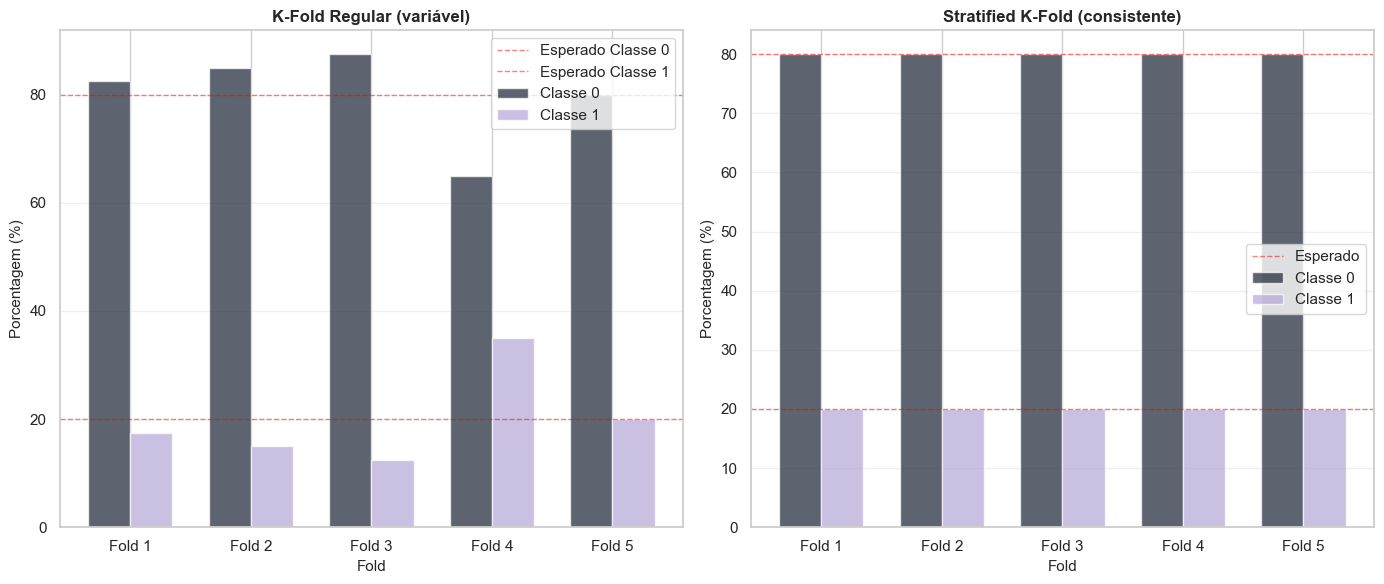

In [13]:
# Visualizar distribuições
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Fold Regular
fold_distributions_regular = []
for train_idx, test_idx in kfold_regular.split(X_imb):
    y_test = y_imb[test_idx]
    fold_distributions_regular.append([
        (y_test == 0).sum() / len(y_test) * 100,
        (y_test == 1).sum() / len(y_test) * 100
    ])

fold_distributions_regular = np.array(fold_distributions_regular)

x_pos = np.arange(5)
width = 0.35

axes[0].bar(x_pos - width/2, fold_distributions_regular[:, 0], width,
            label='Classe 0', color='#1A2332', alpha=0.7)
axes[0].bar(x_pos + width/2, fold_distributions_regular[:, 1], width,
            label='Classe 1', color='#B4A7D6', alpha=0.7)
axes[0].axhline(80, color='red', linestyle='--', linewidth=1,
                alpha=0.5, label='Esperado Classe 0')
axes[0].axhline(20, color='red', linestyle='--', linewidth=1,
                alpha=0.5, label='Esperado Classe 1')
axes[0].set_xlabel('Fold', fontsize=11)
axes[0].set_ylabel('Porcentagem (%)', fontsize=11)
axes[0].set_title('K-Fold Regular (variável)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Fold {i+1}' for i in range(5)])
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Stratified K-Fold
fold_distributions_stratified = []
for train_idx, test_idx in kfold_stratified.split(X_imb, y_imb):
    y_test = y_imb[test_idx]
    fold_distributions_stratified.append([
        (y_test == 0).sum() / len(y_test) * 100,
        (y_test == 1).sum() / len(y_test) * 100
    ])

fold_distributions_stratified = np.array(fold_distributions_stratified)

axes[1].bar(x_pos - width/2, fold_distributions_stratified[:, 0], width,
            label='Classe 0', color='#1A2332', alpha=0.7)
axes[1].bar(x_pos + width/2, fold_distributions_stratified[:, 1], width,
            label='Classe 1', color='#B4A7D6', alpha=0.7)
axes[1].axhline(80, color='red', linestyle='--',
                linewidth=1, alpha=0.5, label='Esperado')
axes[1].axhline(20, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Fold', fontsize=11)
axes[1].set_ylabel('Porcentagem (%)', fontsize=11)
axes[1].set_title('Stratified K-Fold (consistente)',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Fold {i+1}' for i in range(5)])
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [14]:
# Comparar performance
model = LogisticRegression(random_state=42)

scores_regular = cross_val_score(
    model, X_imb, y_imb, cv=kfold_regular, scoring='accuracy')
scores_stratified = cross_val_score(
    model, X_imb, y_imb, cv=kfold_stratified, scoring='accuracy')

print("\nCOMPARAÇÃO DE PERFORMANCE")
print("="*70)

print("\nK-Fold Regular:")
print(f"  Scores: {scores_regular}")
print(f"  Média: {scores_regular.mean():.4f}")
print(f"  Std:   {scores_regular.std():.4f}")

print("\nStratified K-Fold:")
print(f"  Scores: {scores_stratified}")
print(f"  Média: {scores_stratified.mean():.4f}")
print(f"  Std:   {scores_stratified.std():.4f}")

print(
    f"\nRedução no desvio padrão: {((scores_regular.std() - scores_stratified.std()) / scores_regular.std() * 100):.1f}%")


COMPARAÇÃO DE PERFORMANCE

K-Fold Regular:
  Scores: [0.925 0.95  0.875 0.725 0.95 ]
  Média: 0.8850
  Std:   0.0846

Stratified K-Fold:
  Scores: [0.875 0.925 0.875 0.925 0.925]
  Média: 0.9050
  Std:   0.0245

Redução no desvio padrão: 71.0%


---
## 5. Time Series Split Cross-Validation

### O Problema com Dados Temporais

**K-Fold e Stratified K-Fold NÃO funcionam para séries temporais!**

**Por quê?**
- Dados futuros não podem ser usados para prever o passado
- Viola ordem temporal
- Causa data leakage
- Resultados irrealistas

### Conceito de Time Series Split

**Time Series Split:** Respeita a ordem temporal dos dados.

### Propriedades

1. Treino sempre vem antes do teste
2. Não há overlap temporal
3. Simula cenário real de produção
4. Conjunto de treino cresce (ou desliza)

### Vantagens

- Respeita ordem temporal
- Evita data leakage
- Realista para produção
- Testa em diferentes períodos

### Desvantagens

- Menos folds disponíveis
- Primeiros modelos têm menos dados
- Pode ser sensível a mudanças de conceito

### Quando Usar

- Dados de séries temporais
- Previsão de estoque, vendas, etc.
- Dados financeiros
- Qualquer dado com ordem temporal importante

---

In [15]:
# Criar dados de série temporal
np.random.seed(42)

# Série temporal simples: tendência + sazonalidade + ruído
n_samples = 200
time = np.arange(n_samples)
trend = 0.5 * time
seasonality = 10 * np.sin(2 * np.pi * time / 50)
noise = np.random.normal(0, 5, n_samples)
y_ts = trend + seasonality + noise

# Features baseadas em tempo
X_ts = np.column_stack([
    time,
    np.sin(2 * np.pi * time / 50),
    np.cos(2 * np.pi * time / 50)
])

print("DADOS DE SÉRIE TEMPORAL")
print("="*70)
print(f"Total de amostras: {len(X_ts)}")
print(f"Features: {X_ts.shape[1]}")

DADOS DE SÉRIE TEMPORAL
Total de amostras: 200
Features: 3


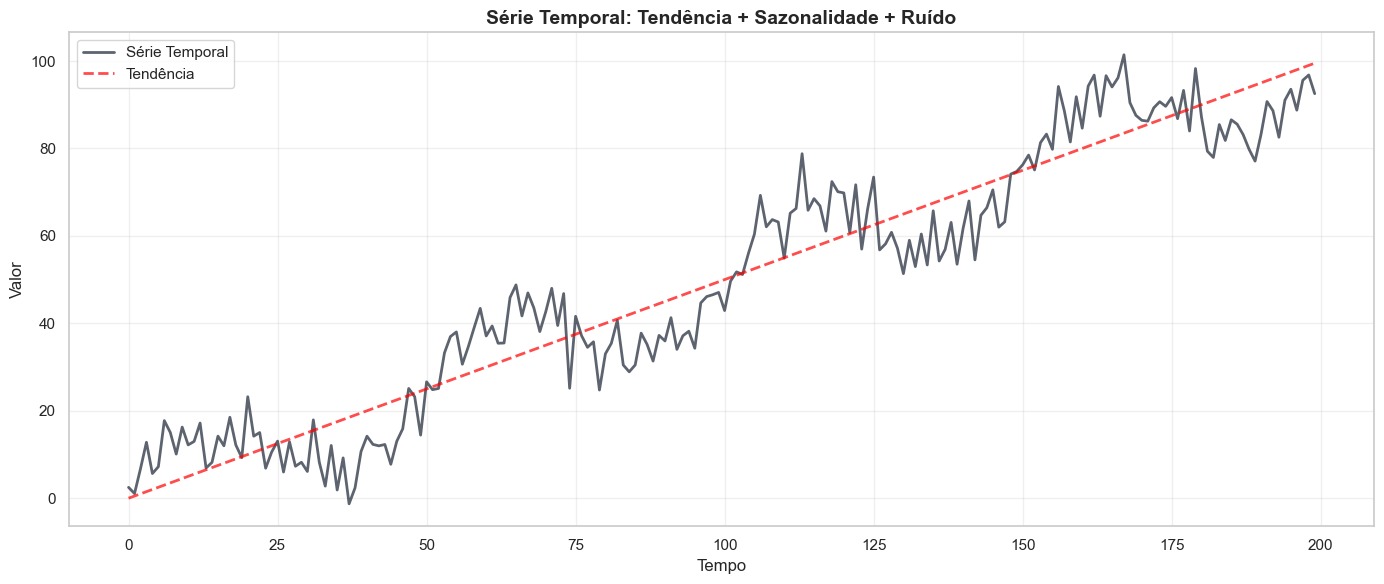

In [16]:
# Visualizar série temporal
plt.figure(figsize=(14, 6))
plt.plot(time, y_ts, linewidth=2, color='#1A2332',
         alpha=0.7, label='Série Temporal')
plt.plot(time, trend, '--', color='red',
         linewidth=2, alpha=0.7, label='Tendência')
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.title('Série Temporal: Tendência + Sazonalidade + Ruído',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Demonstrar Time Series Split
tscv = TimeSeriesSplit(n_splits=5)

print("\nTIME SERIES SPLIT CROSS-VALIDATION")
print("="*70)

fold_num = 1
for train_idx, test_idx in tscv.split(X_ts):
    print(f"\nFold {fold_num}:")
    print(
        f"  Treino: índices {train_idx[0]:3d} a {train_idx[-1]:3d} ({len(train_idx):3d} amostras)")
    print(
        f"  Teste:  índices {test_idx[0]:3d} a {test_idx[-1]:3d} ({len(test_idx):3d} amostras)")
    fold_num += 1

print("\nObservação: Treino sempre vem ANTES do teste na linha do tempo!")


TIME SERIES SPLIT CROSS-VALIDATION

Fold 1:
  Treino: índices   0 a  34 ( 35 amostras)
  Teste:  índices  35 a  67 ( 33 amostras)

Fold 2:
  Treino: índices   0 a  67 ( 68 amostras)
  Teste:  índices  68 a 100 ( 33 amostras)

Fold 3:
  Treino: índices   0 a 100 (101 amostras)
  Teste:  índices 101 a 133 ( 33 amostras)

Fold 4:
  Treino: índices   0 a 133 (134 amostras)
  Teste:  índices 134 a 166 ( 33 amostras)

Fold 5:
  Treino: índices   0 a 166 (167 amostras)
  Teste:  índices 167 a 199 ( 33 amostras)

Observação: Treino sempre vem ANTES do teste na linha do tempo!


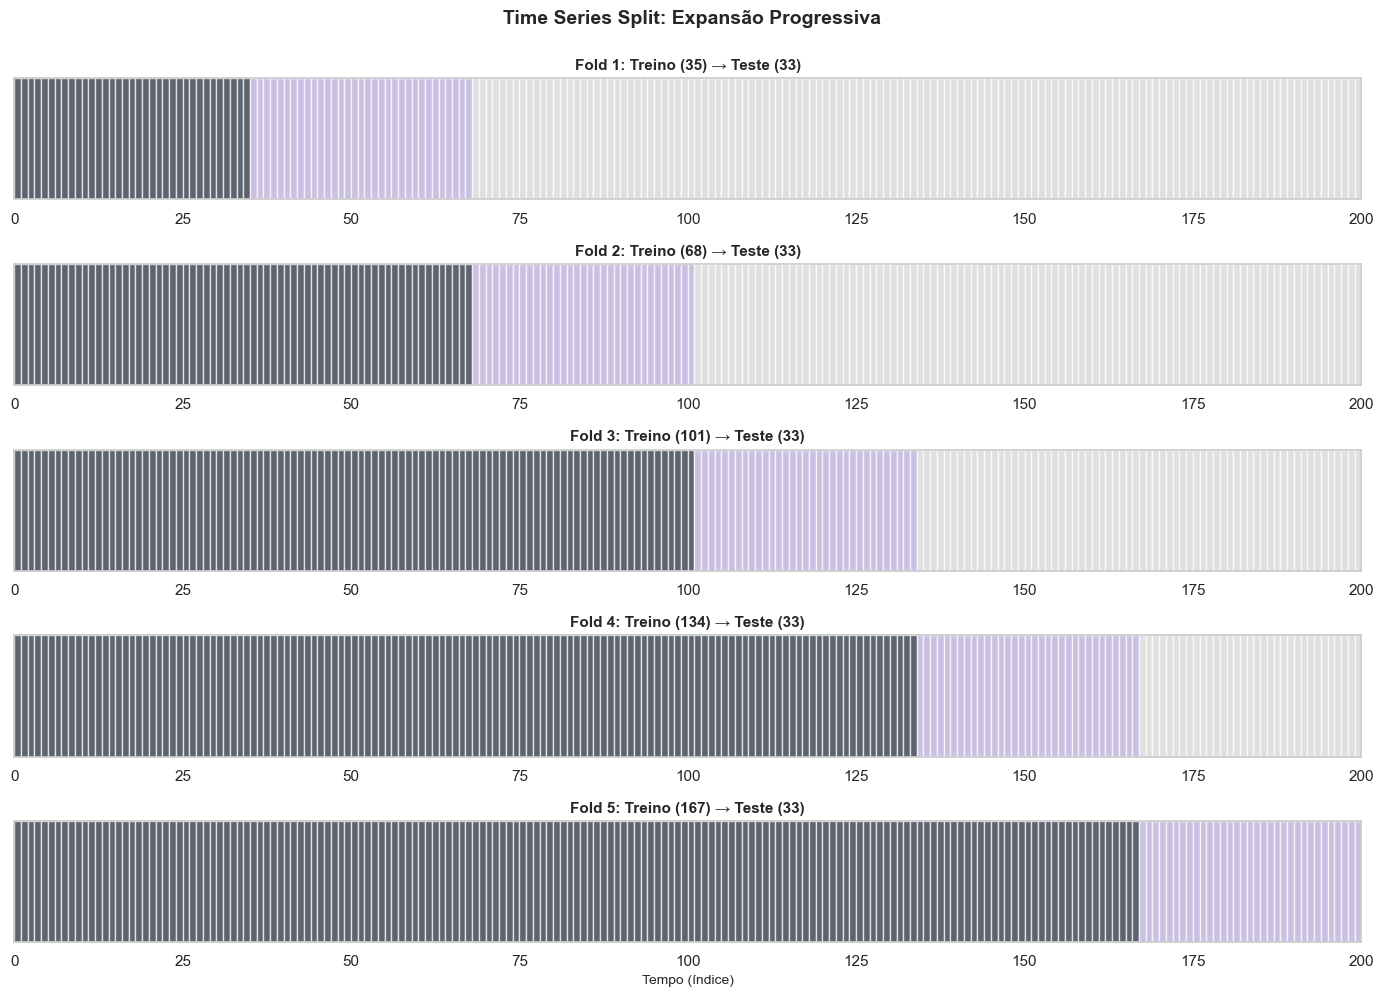


Cada fold tem mais dados de treino que o anterior (expansão)


In [18]:
# Visualizar splits
fig, axes = plt.subplots(5, 1, figsize=(14, 10))

fold_num = 1
for (train_idx, test_idx), ax in zip(tscv.split(X_ts), axes):
    # Criar array de cores
    colors_array = np.full(len(X_ts), 'lightgray', dtype=object)
    colors_array[train_idx] = '#1A2332'  # Treino = azul escuro
    colors_array[test_idx] = '#B4A7D6'   # Teste = roxo

    # Plot
    for i, color in enumerate(colors_array):
        ax.axvspan(i, i+1, facecolor=color, alpha=0.7)

    ax.set_xlim(0, len(X_ts))
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel('Tempo (índice)' if fold_num == 5 else '', fontsize=10)
    ax.set_title(f'Fold {fold_num}: Treino ({len(train_idx)}) → Teste ({len(test_idx)})',
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

    fold_num += 1

plt.suptitle('Time Series Split: Expansão Progressiva',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\nCada fold tem mais dados de treino que o anterior (expansão)")

In [19]:
# Avaliar modelo com Time Series Split
model_ts = LinearRegression()
scores_ts = []

print("\nAVALIAÇÃO COM TIME SERIES SPLIT")
print("="*70)

fold_num = 1
for train_idx, test_idx in tscv.split(X_ts):
    X_train, X_test = X_ts[train_idx], X_ts[test_idx]
    y_train, y_test = y_ts[train_idx], y_ts[test_idx]

    # Treinar
    model_ts.fit(X_train, y_train)

    # Avaliar
    score = r2_score(y_test, model_ts.predict(X_test))
    scores_ts.append(score)

    print(f"Fold {fold_num}: R² = {score:.4f}")
    fold_num += 1

print(f"\nMédia R²: {np.mean(scores_ts):.4f}")
print(f"Std R²:   {np.std(scores_ts):.4f}")


AVALIAÇÃO COM TIME SERIES SPLIT
Fold 1: R² = 0.8267
Fold 2: R² = 0.3840
Fold 3: R² = 0.5070
Fold 4: R² = 0.8986
Fold 5: R² = 0.3508

Média R²: 0.5934
Std R²:   0.2270


In [20]:
# Comparar com K-Fold (ERRADO para séries temporais!)
kfold_wrong = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kfold_wrong = cross_val_score(
    model_ts, X_ts, y_ts, cv=kfold_wrong, scoring='r2')

print("\nCOMPARAÇÃO: TIME SERIES SPLIT VS K-FOLD (ERRADO)")
print("="*70)

print("\nTime Series Split (correto):")
print(f"  Média R²: {np.mean(scores_ts):.4f}")
print(f"  Std R²:   {np.std(scores_ts):.4f}")

print("\nK-Fold (ERRADO para séries temporais):")
print(f"  Média R²: {np.mean(scores_kfold_wrong):.4f}")
print(f"  Std R²:   {np.std(scores_kfold_wrong):.4f}")

print("\nProblema: K-Fold usa dados futuros para prever o passado!")
print("Resultado otimista e não realista!")


COMPARAÇÃO: TIME SERIES SPLIT VS K-FOLD (ERRADO)

Time Series Split (correto):
  Média R²: 0.5934
  Std R²:   0.2270

K-Fold (ERRADO para séries temporais):
  Média R²: 0.9732
  Std R²:   0.0077

Problema: K-Fold usa dados futuros para prever o passado!
Resultado otimista e não realista!


### Por que K-Fold Falha em Séries Temporais?

**Exemplo Visual:**

**K-Fold (ERRADO):**

Fold 1: Treino [1,2,6,7,8] | Teste [3,4,5]  ❌ Dados futuros no treino!

**Time Series Split (CORRETO):**

Fold 1: Treino [1,2,3] | Teste [4,5]  ✅ Ordem temporal respeitada

### Data Leakage

Usar dados futuros no treino = modelo vê o futuro = previsões irrealistas

---
## 6. Leave-One-Out Cross-Validation (LOOCV)

### Conceito

**LOOCV:** Caso extremo de K-Fold onde:

$$
K = n
$$

onde \( n \) é o número de amostras.

---

### Fórmula

O score final é dado por:

$$
\text{Score}_{\text{final}} = \frac{1}{n} \sum_{i=1}^{n} \text{Score}_i
$$

---

### Vantagens

- Máximo uso dos dados (\(n-1\) para treino)
- Quase sem viés
- Determinístico (sem aleatoriedade)
- Útil para datasets muito pequenos

---

### Desvantagens

- Muito lento (treina \(n\) modelos)
- Alta variância
- Computacionalmente caro
- Impraticável para datasets grandes

---

### Quando Usar

- Dataset muito pequeno (\(n < 100\))
- Cada amostra é valiosa
- Tempo de treino é aceitável
- Máxima utilização dos dados é crucial

---

### Quando **NÃO** Usar

- Dataset grande (\(n > 1000\))
- Tempo é limitado
- Recursos computacionais limitados
- Alta variância é um problema
---


In [21]:
# Criar dataset pequeno para LOOCV
X_small, y_small = make_classification(
    n_samples=50,  # Dataset pequeno
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

print("LEAVE-ONE-OUT CROSS-VALIDATION")
print("="*70)
print(f"Total de amostras: {len(X_small)}")
print(f"Número de folds (= número de amostras): {len(X_small)}")
print(f"Cada fold terá:")
print(f"  Treino: {len(X_small) - 1} amostras")
print(f"  Teste: 1 amostra")

LEAVE-ONE-OUT CROSS-VALIDATION
Total de amostras: 50
Número de folds (= número de amostras): 50
Cada fold terá:
  Treino: 49 amostras
  Teste: 1 amostra


In [22]:
# Implementar LOOCV
loo = LeaveOneOut()

print("\nPRIMEIROS 5 FOLDS:")
print("-" * 70)

fold_num = 1
for train_idx, test_idx in loo.split(X_small):
    if fold_num <= 5:
        print(
            f"Fold {fold_num}: Treino = {len(train_idx)} amostras, Teste = índice {test_idx[0]}")
    fold_num += 1

print(f"... (continuaria até fold {len(X_small)})")


PRIMEIROS 5 FOLDS:
----------------------------------------------------------------------
Fold 1: Treino = 49 amostras, Teste = índice 0
Fold 2: Treino = 49 amostras, Teste = índice 1
Fold 3: Treino = 49 amostras, Teste = índice 2
Fold 4: Treino = 49 amostras, Teste = índice 3
Fold 5: Treino = 49 amostras, Teste = índice 4
... (continuaria até fold 50)


In [23]:
# Avaliar com LOOCV
import time

model = LogisticRegression(random_state=42)

print("\nEXECUTANDO LOOCV...")
start_time = time.time()
scores_loo = cross_val_score(
    model, X_small, y_small, cv=loo, scoring='accuracy')
end_time = time.time()

print(f"Tempo de execução: {end_time - start_time:.2f} segundos")
print(f"Número de modelos treinados: {len(scores_loo)}")
print(f"\nMédia de acurácia: {scores_loo.mean():.4f}")
print(f"Std de acurácia:   {scores_loo.std():.4f}")
print(f"Mínimo: {scores_loo.min():.4f}")
print(f"Máximo: {scores_loo.max():.4f}")

# Observação sobre cada score
print(f"\nObservação: Cada score é 0 ou 1 (erro ou acerto)")
print(f"Scores únicos: {np.unique(scores_loo)}")


EXECUTANDO LOOCV...
Tempo de execução: 0.17 segundos
Número de modelos treinados: 50

Média de acurácia: 0.9400
Std de acurácia:   0.2375
Mínimo: 0.0000
Máximo: 1.0000

Observação: Cada score é 0 ou 1 (erro ou acerto)
Scores únicos: [0. 1.]


In [24]:
# Comparar LOOCV com K-Fold
k_values = [3, 5, 10]
results_comparison = []

# LOOCV
results_comparison.append({
    'Método': 'LOOCV',
    'K': len(X_small),
    'Treino por fold': len(X_small) - 1,
    'Teste por fold': 1,
    'Total modelos': len(X_small),
    'Média': scores_loo.mean(),
    'Std': scores_loo.std()
})

# K-Fold com diferentes K
for k in k_values:
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_k = cross_val_score(
        model, X_small, y_small, cv=kfold, scoring='accuracy')

    results_comparison.append({
        'Método': f'{k}-Fold',
        'K': k,
        'Treino por fold': len(X_small) * (k-1) // k,
        'Teste por fold': len(X_small) // k,
        'Total modelos': k,
        'Média': scores_k.mean(),
        'Std': scores_k.std()
    })

# Criar DataFrame
df_comparison = pd.DataFrame(results_comparison)

print("\nCOMPARAÇÃO: LOOCV VS K-FOLD")
print("="*70)
print(df_comparison.to_string(index=False))

print("\nObservações:")
print("- LOOCV treina MUITO mais modelos")
print("- LOOCV usa mais dados para treino")
print("- LOOCV tem maior variância (std)")


COMPARAÇÃO: LOOCV VS K-FOLD
 Método  K  Treino por fold  Teste por fold  Total modelos    Média      Std
  LOOCV 50               49               1             50 0.940000 0.237487
 3-Fold  3               33              16              3 0.959559 0.028636
 5-Fold  5               40              10              5 0.960000 0.048990
10-Fold 10               45               5             10 0.960000 0.080000

Observações:
- LOOCV treina MUITO mais modelos
- LOOCV usa mais dados para treino
- LOOCV tem maior variância (std)


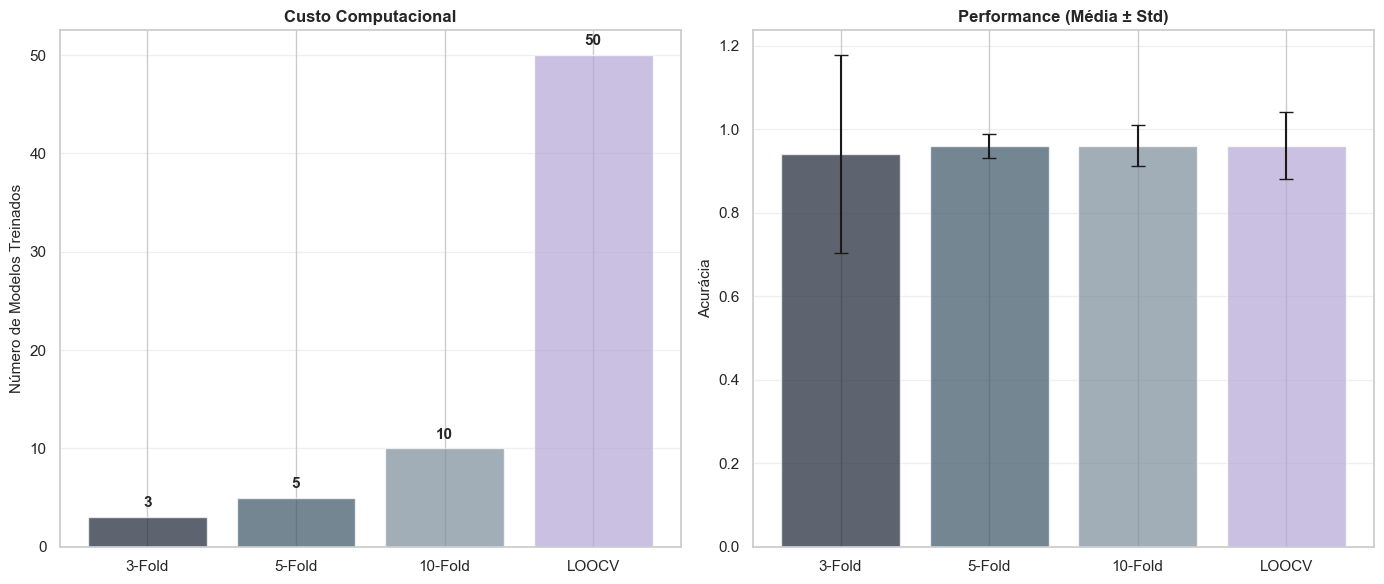

In [25]:
# Visualizar comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Número de modelos treinados
methods = ['3-Fold', '5-Fold', '10-Fold', 'LOOCV']
n_models = [3, 5, 10, len(X_small)]

axes[0].bar(methods, n_models, color=['#1A2332',
            '#3B5366', '#7A8B99', '#B4A7D6'], alpha=0.7)
axes[0].set_ylabel('Número de Modelos Treinados', fontsize=11)
axes[0].set_title('Custo Computacional', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

for i, v in enumerate(n_models):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: Média e Std
means = df_comparison['Média'].values
stds = df_comparison['Std'].values

x_pos = np.arange(len(methods))
axes[1].bar(x_pos, means, yerr=stds, capsize=5,
            color=['#1A2332', '#3B5366', '#7A8B99', '#B4A7D6'], alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel('Acurácia', fontsize=11)
axes[1].set_title('Performance (Média ± Std)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Complexidade Computacional

**K-Fold:** O(K × tempo_treino)
**LOOCV:** O(n × tempo_treino)

**Exemplo com n=1000:**
- 5-Fold: 5 modelos
- LOOCV: 1000 modelos (200x mais lento!)

---
## 7. Comparação Prática

### Resumo de Todas as Técnicas

In [26]:
# Comparação abrangente
print("COMPARAÇÃO ABRANGENTE DE TODAS AS TÉCNICAS")
print("="*70)

# Usar dataset balanceado para comparação justa
X_comp, y_comp = make_classification(
    n_samples=200,
    n_features=5,
    n_informative=5,
    n_redundant=0,
    random_state=42
)

model = LogisticRegression(random_state=42, max_iter=1000)

# Lista de métodos
methods_cv = {
    'Train/Test Split (1x)': None,
    '3-Fold CV': KFold(n_splits=3, shuffle=True, random_state=42),
    '5-Fold CV': KFold(n_splits=5, shuffle=True, random_state=42),
    '10-Fold CV': KFold(n_splits=10, shuffle=True, random_state=42),
    'Stratified 5-Fold': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'LOOCV': LeaveOneOut()
}

results_all = []

for method_name, cv_method in methods_cv.items():
    if method_name == 'Train/Test Split (1x)':
        # Train/Test split simples
        X_train, X_test, y_train, y_test = train_test_split(
            X_comp, y_comp, test_size=0.2, random_state=42
        )
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)

        results_all.append({
            'Método': method_name,
            'N° Folds': 1,
            'Média': score,
            'Std': 0,
            'Min': score,
            'Max': score
        })
    else:
        # Cross-validation
        start = time.time()
        scores = cross_val_score(
            model, X_comp, y_comp, cv=cv_method, scoring='accuracy')
        elapsed = time.time() - start

        results_all.append({
            'Método': method_name,
            'N° Folds': len(scores),
            'Média': scores.mean(),
            'Std': scores.std(),
            'Min': scores.min(),
            'Max': scores.max(),
            'Tempo (s)': elapsed
        })

df_results = pd.DataFrame(results_all)
print("\n" + df_results.to_string(index=False))

COMPARAÇÃO ABRANGENTE DE TODAS AS TÉCNICAS

               Método  N° Folds    Média      Std      Min      Max  Tempo (s)
Train/Test Split (1x)         1 0.750000 0.000000 0.750000 0.750000        NaN
            3-Fold CV         3 0.729911 0.022190 0.712121 0.761194   0.016975
            5-Fold CV         5 0.720000 0.029155 0.675000 0.750000   0.030908
           10-Fold CV        10 0.720000 0.060000 0.600000 0.800000   0.051556
    Stratified 5-Fold         5 0.745000 0.078102 0.650000 0.850000   0.019497
                LOOCV       200 0.730000 0.443959 0.000000 1.000000   0.683978


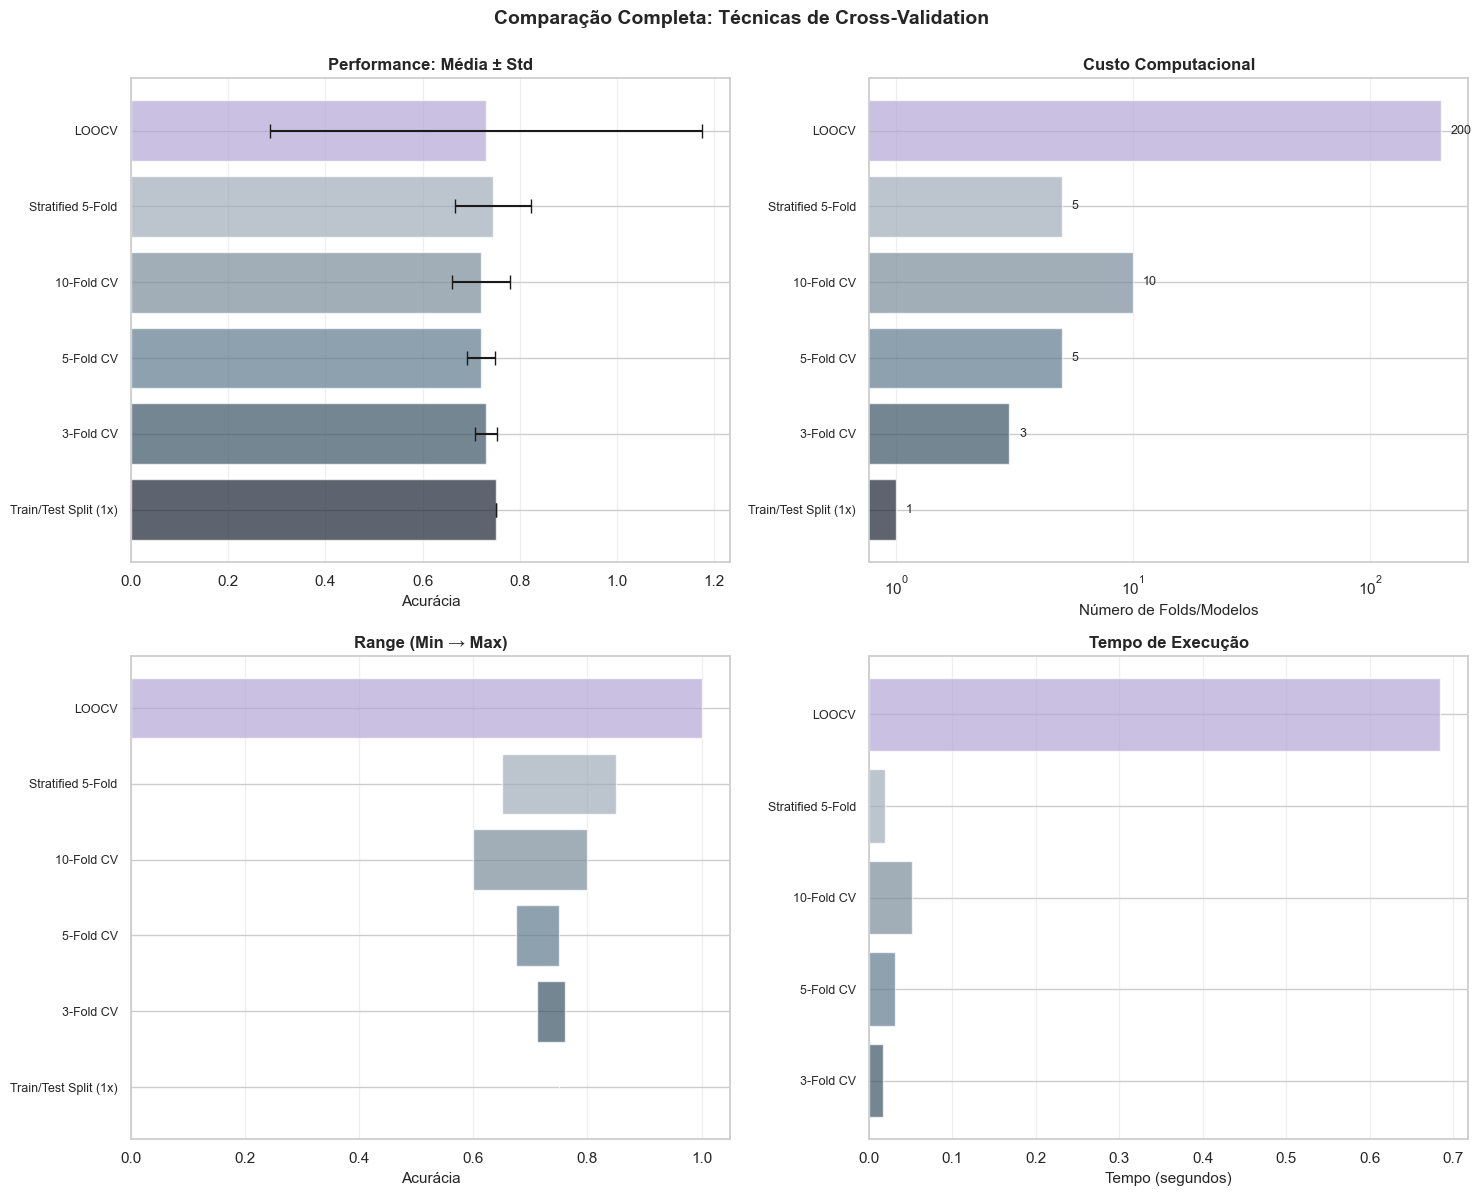

In [27]:
# Visualização comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Média e Std
ax = axes[0, 0]
methods_names = df_results['Método'].values
means = df_results['Média'].values
stds = df_results['Std'].values

x_pos = np.arange(len(methods_names))
colors_bars = ['#1A2332', '#3B5366',
               '#5D7A8C', '#7A8B99', '#A0ADB8', '#B4A7D6']

bars = ax.barh(x_pos, means, xerr=stds, capsize=5,
               color=colors_bars, alpha=0.7)
ax.set_yticks(x_pos)
ax.set_yticklabels(methods_names, fontsize=9)
ax.set_xlabel('Acurácia', fontsize=11)
ax.set_title('Performance: Média ± Std', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Gráfico 2: Número de folds
ax = axes[0, 1]
n_folds = df_results['N° Folds'].values
bars = ax.barh(x_pos, n_folds, color=colors_bars, alpha=0.7)
ax.set_yticks(x_pos)
ax.set_yticklabels(methods_names, fontsize=9)
ax.set_xlabel('Número de Folds/Modelos', fontsize=11)
ax.set_title('Custo Computacional', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.grid(alpha=0.3, axis='x')

# Adicionar valores
for i, v in enumerate(n_folds):
    ax.text(v * 1.1, i, str(v), va='center', fontsize=9)

# Gráfico 3: Range (Min-Max)
ax = axes[1, 0]
mins = df_results['Min'].values
maxs = df_results['Max'].values
ranges = maxs - mins

ax.barh(x_pos, ranges, left=mins, color=colors_bars, alpha=0.7)
ax.set_yticks(x_pos)
ax.set_yticklabels(methods_names, fontsize=9)
ax.set_xlabel('Acurácia', fontsize=11)
ax.set_title('Range (Min → Max)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Gráfico 4: Tempo de execução
ax = axes[1, 1]
if 'Tempo (s)' in df_results.columns:
    times = df_results['Tempo (s)'].fillna(
        0).values[1:]  # Excluir train/test split
    methods_cv_only = methods_names[1:]
    x_pos_cv = np.arange(len(methods_cv_only))

    ax.barh(x_pos_cv, times, color=colors_bars[1:], alpha=0.7)
    ax.set_yticks(x_pos_cv)
    ax.set_yticklabels(methods_cv_only, fontsize=9)
    ax.set_xlabel('Tempo (segundos)', fontsize=11)
    ax.set_title('Tempo de Execução', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

plt.suptitle('Comparação Completa: Técnicas de Cross-Validation',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

---
## 8. Quando Usar Cada Técnica

### Tabela de Decisão

In [28]:
# Criar guia de decisão
decision_guide = pd.DataFrame({
    'Técnica': [
        'Train/Test Split',
        'K-Fold (k=5 ou 10)',
        'Stratified K-Fold',
        'Time Series Split',
        'Leave-One-Out'
    ],
    'Dataset': [
        'Qualquer tamanho',
        'Médio a Grande',
        'Desbalanceado',
        'Séries Temporais',
        'Muito Pequeno (<100)'
    ],
    'Vantagem Principal': [
        'Rápido, simples',
        'Balanceado, confiável',
        'Mantém proporções',
        'Respeita ordem temporal',
        'Máximo uso dos dados'
    ],
    'Desvantagem': [
        'Alta variância',
        'Mais lento',
        'Requer labels',
        'Menos folds',
        'Muito lento'
    ],
    'Custo Computacional': [
        'Baixo (1 modelo)',
        'Médio (k modelos)',
        'Médio (k modelos)',
        'Médio (k modelos)',
        'Alto (n modelos)'
    ]
})

print("\nGUIA DE DECISÃO: QUAL TÉCNICA USAR?")
print("="*70)
print(decision_guide.to_string(index=False))


GUIA DE DECISÃO: QUAL TÉCNICA USAR?
           Técnica              Dataset      Vantagem Principal    Desvantagem Custo Computacional
  Train/Test Split     Qualquer tamanho         Rápido, simples Alta variância    Baixo (1 modelo)
K-Fold (k=5 ou 10)       Médio a Grande   Balanceado, confiável     Mais lento   Médio (k modelos)
 Stratified K-Fold        Desbalanceado       Mantém proporções  Requer labels   Médio (k modelos)
 Time Series Split     Séries Temporais Respeita ordem temporal    Menos folds   Médio (k modelos)
     Leave-One-Out Muito Pequeno (<100)    Máximo uso dos dados    Muito lento    Alto (n modelos)


### Fluxograma de Decisão

**Início**

➡️ **Os dados têm ordem temporal importante?**  
- ✅ **Sim** → *Time Series Split*  
- ❌ **Não** → continuar  

➡️ **O dataset é muito pequeno (n < 100)?**  
- ✅ **Sim** → *Leave-One-Out*  
- ❌ **Não** → continuar  

➡️ **As classes estão desbalanceadas?**  
- ✅ **Sim** → *Stratified K-Fold*  
- ❌ **Não** → *K-Fold (k = 5 ou 10)*  

➡️ **Apenas validação rápida?**  
- ✅ **Sim** → *Train/Test Split*

### Recomendações por Cenário

**Classificação Balanceada:**
→ K-Fold (k=10)

**Classificação Desbalanceada:**
→ Stratified K-Fold (k=5 ou 10)

**Regressão:**
→ K-Fold (k=5 ou 10)

**Séries Temporais:**
→ Time Series Split

**Dataset Pequeno (<100):**
→ Leave-One-Out ou K-Fold com k alto

**Dataset Gigante (>100k):**
→ Train/Test Split ou K-Fold com k pequeno (k=3)

**Exploração Rápida:**
→ Train/Test Split (80/20)

**Tuning de Hiperparâmetros:**
→ Stratified K-Fold com GridSearchCV

---
## 9. Implementação Completa

### Pipeline Completo com Cross-Validation

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

print("PIPELINE COMPLETO COM CROSS-VALIDATION")
print("="*70)

# Criar pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

# Definir grid de hiperparâmetros
param_grid = {
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

# Grid Search com Stratified K-Fold
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Treinar
print("\nExecutando Grid Search com 5-Fold CV...")
grid_search.fit(X_comp, y_comp)

print(f"\nMelhores hiperparâmetros: {grid_search.best_params_}")
print(f"Melhor score (CV): {grid_search.best_score_:.4f}")

# Resultados detalhados
results_grid = pd.DataFrame(grid_search.cv_results_)
print("\nTop 3 configurações:")
print(results_grid[['params', 'mean_test_score', 'std_test_score']].sort_values(
    'mean_test_score', ascending=False
).head(3).to_string(index=False))

PIPELINE COMPLETO COM CROSS-VALIDATION

Executando Grid Search com 5-Fold CV...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Melhores hiperparâmetros: {'classifier__C': 1.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Melhor score (CV): 0.7500

Top 3 configurações:
                                                                             params  mean_test_score  std_test_score
 {'classifier__C': 1.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}            0.750        0.072457
{'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}            0.745        0.078102
 {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}            0.740        0.053852


In [30]:
# cross_validate: mais informações
from sklearn.model_selection import cross_validate

print("\nUSANDO cross_validate PARA MÚLTIPLAS MÉTRICAS")
print("="*70)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

cv_results = cross_validate(
    pipeline,
    X_comp, y_comp,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True
)

# Mostrar resultados
metrics_summary = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Treino (média)': [
        cv_results['train_accuracy'].mean(),
        cv_results['train_precision'].mean(),
        cv_results['train_recall'].mean(),
        cv_results['train_f1'].mean()
    ],
    'Teste (média)': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean()
    ],
    'Teste (std)': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std()
    ]
})

print("\n" + metrics_summary.to_string(index=False))


USANDO cross_validate PARA MÚLTIPLAS MÉTRICAS

  Métrica  Treino (média)  Teste (média)  Teste (std)
 Accuracy        0.751250       0.750000     0.072457
Precision        0.753201       0.755922     0.071141
   Recall        0.751642       0.750426     0.073048
 F1-Score        0.750923       0.748164     0.073754



LEARNING CURVES


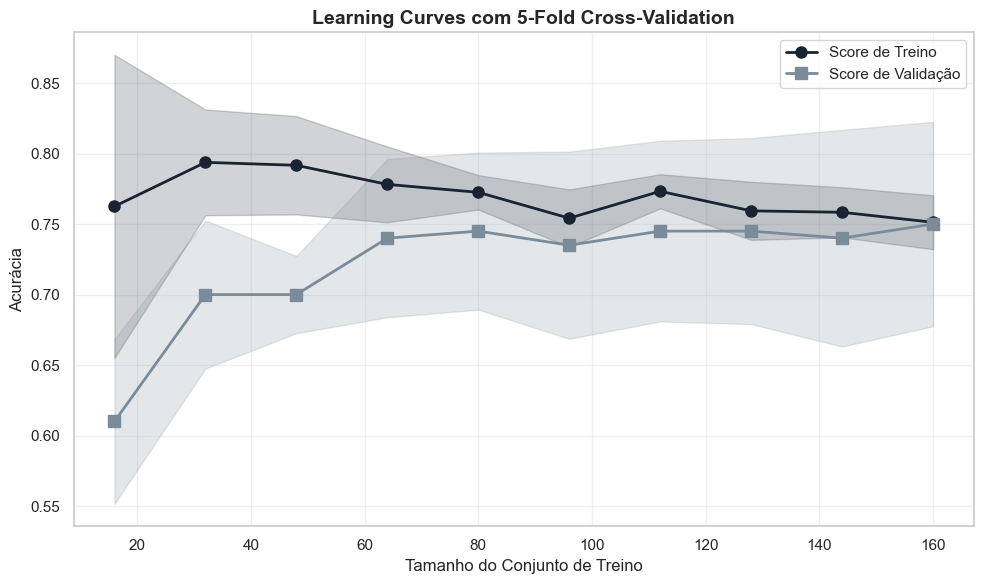


Interpretação:
- Se curvas convergem: modelo está generalizando bem
- Se curvas estão distantes: possível overfitting
- Se ambas baixas: possível underfitting


In [31]:
# Visualizar learning curves
from sklearn.model_selection import learning_curve

print("\nLEARNING CURVES")
print("="*70)

train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X_comp, y_comp,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

# Calcular médias e stds
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', color='#1A2332',
         linewidth=2, markersize=8, label='Score de Treino')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='#1A2332')

plt.plot(train_sizes, test_mean, 's-', color='#7A8B99',
         linewidth=2, markersize=8, label='Score de Validação')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 alpha=0.2, color='#7A8B99')

plt.xlabel('Tamanho do Conjunto de Treino', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.title('Learning Curves com 5-Fold Cross-Validation',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("- Se curvas convergem: modelo está generalizando bem")
print("- Se curvas estão distantes: possível overfitting")
print("- Se ambas baixas: possível underfitting")

---
## 10. Resumo e Boas Práticas

### Principais Conceitos

**1. Cross-Validation resolve:**
- Variância de um único split
- Maximiza uso dos dados
- Fornece estimativa mais confiável

**2. Escolha da técnica depende de:**
- Tipo de dados (temporal? desbalanceado?)
- Tamanho do dataset
- Recursos computacionais
- Objetivo da validação

**3. K recomendados:**
- k=5: Bom balanço, rápido
- k=10: Mais comum, padrão
- k=n: Máximo uso (pequenos datasets)

### Boas Práticas

**1. SEMPRE use CV para:**
- Avaliar modelos finais
- Comparar diferentes algoritmos
- Tuning de hiperparâmetros
- Reportar resultados

**2. NUNCA:**
- Use dados de teste para qualquer decisão
- Faça feature selection sem CV
- Otimize no conjunto de teste
- Ignore a ordem temporal em séries

**3. Reporte SEMPRE:**
- Média E desvio padrão
- Número de folds usado
- Tipo de CV (stratified? time series?)
- Intervalo de confiança (opcional)

**4. Cuidados:**
- Fit do scaler/preprocessamento dentro do CV
- Não vazamento de dados (data leakage)
- Stratify para dados desbalanceados
- Time-aware para séries temporais

### Exemplo de Reporte

"O modelo Logistic Regression obteve acurácia média de 0.857 ± 0.023 
(média ± std) usando 10-fold cross-validation stratificado."

### Recursos Computacionais

**Trade-off Tempo vs Precisão:**
- Exploração: Train/Test Split
- Desenvolvimento: 5-Fold CV
- Avaliação Final: 10-Fold CV ou LOOCV
- Produção: Validação em dados holdout

### Erros Comuns a Evitar

**1. Data Leakage:**
```python
# ❌ ERRADO
scaler.fit(X)  # Fit em todos os dados
X_scaled = scaler.transform(X)
scores = cross_val_score(model, X_scaled, y, cv=5)

# ✅ CORRETO
pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
scores = cross_val_score(pipeline, X, y, cv=5)
```

**2. Usar K-Fold em Séries Temporais:**
```python
# ❌ ERRADO
cv = KFold(n_splits=5)

# ✅ CORRETO
cv = TimeSeriesSplit(n_splits=5)
```

**3. Não Usar Stratified em Dados Desbalanceados:**
```python
# ❌ ERRADO (para dados desbalanceados)
cv = KFold(n_splits=5)

# ✅ CORRETO
cv = StratifiedKFold(n_splits=5)
```

### Checklist Final

- [ ] Tipo de CV adequado ao problema?
- [ ] K escolhido apropriadamente?
- [ ] Stratify se classes desbalanceadas?
- [ ] Preprocessing dentro do CV?
- [ ] Reportando média E std?
- [ ] Seed fixada para reprodutibilidade?
- [ ] Tempo de execução aceitável?

---